In [1]:
import matplotlib.pyplot as plt
import numpy as np
import graph_style as gs
from scipy.optimize import curve_fit
from matplotlib.ticker import FormatStrFormatter
import fig_helper as fh

gs.set_graph_style(1.0)


In [28]:
date = "2026-03-25"
rid_dur = 99417

dict_dur = fh.load_data(rid_dur, date)

In [48]:



def detune_sdf(x, W):
    """
    x is detuning in radians/s
    nbar is initial thermal phonon number
    W is the SDF Rabi frequency in radians/s
    """
    nbar = 0.0#3  # measured temperature
    t = 100e-6
    a = W * np.sinc(x * t / (2 * np.pi)) * t / 2  # numpy normalised sinc
    return 1 / 2 * (1 + np.exp(-4 * (nbar + 1 / 2) * a**2))


def get_pops(dict):
    duration = np.array(dict_dur["datasets"][f"ndscan.rid_{rid_dur}.points.axis_0"])*1e6
    p00 = np.array(
        dict_dur["datasets"][
            f"ndscan.rid_{rid_dur}.points.channel_readout_p_00"
        ]
    )
    p01_10 = np.array(
        dict_dur["datasets"][
            f"ndscan.rid_{rid_dur}.points.channel_readout_p_01_10"
        ]
    )
    p11 = np.array(
        dict_dur["datasets"][
            f"ndscan.rid_{rid_dur}.points.channel_readout_p_11"
        ]
    )
    p00_err = np.array(
        dict_dur["datasets"][
            f"ndscan.rid_{rid_dur}.points.channel_readout_p_err_00"
        ]
    )
    p01_10_err = np.array(
        dict_dur["datasets"][
            f"ndscan.rid_{rid_dur}.points.channel_readout_p_err_01_10"
        ]
    )
    p11_err = np.array(     
        dict_dur["datasets"][
            f"ndscan.rid_{rid_dur}.points.channel_readout_p_err_11"
        ]
    )   
    return duration, p00, p01_10, p11, p00_err, p01_10_err, p11_err


duration, p00, p01_10, p11, p00_err, p01_10_err, p11_err = get_pops(dict_dur)


<Figure size 582.677x360.114 with 0 Axes>

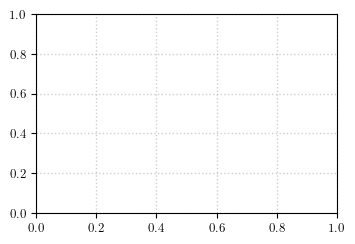

In [49]:
# creating grid for subplots
fig = plt.figure()

fig_width = gs.get_fig_width()*2/3
fig_height =  fig_width*2/3
fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))


Pop error: 0.013 ± 0.002
Contrast: 0.973 ± 0.012
Fidelity: 0.980 ± 0.006


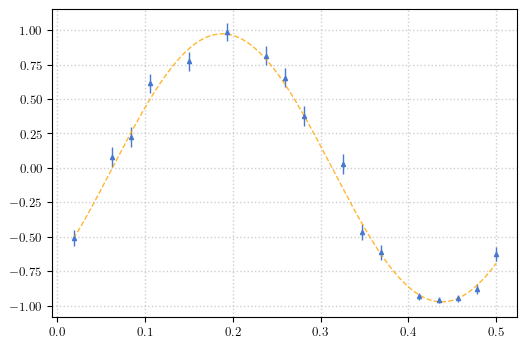

In [52]:

def load_ms_data(rid, date):
    f = fh.load_data(rid, date)


    p00 = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_p_00"])
    p0110 = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_p_01_10"])
    p11 = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_p_11"])
    p_err_00 = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_p_err_00"])
    p_err_0110 = np.array(
        f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_p_err_01_10"]
    )
    p_err_11 = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_p_err_11"])

    x = np.array(f["datasets"][f"ndscan.rid_{rid}.points.axis_0"])

    # get args for x>0
    phase_args = np.where(x > 0)
    phase = x[phase_args]
    par_p00 = p00[phase_args]
    par_p0110 = p0110[phase_args]
    par_p11 = p11[phase_args]
    par_err_p00 = p_err_00[phase_args]
    par_err_p0110 = p_err_0110[phase_args]
    par_err_p11 = p_err_11[phase_args]
    parity = par_p00 + par_p11 - par_p0110
    parity_err = np.sqrt(par_err_p00**2 + par_err_p11**2 + par_err_p0110**2)


    pop_args = np.where(x < 0)
    pop_reps = x[pop_args]
    pop_p00 = p00[pop_args]
    pop_p0110 = p0110[pop_args]
    pop_p11 = p11[pop_args]
    pop_err_p00 = p_err_00[pop_args]
    pop_err_p0110 = p_err_0110[pop_args]
    pop_err_p11 = p_err_11[pop_args]

    p0110_avg = np.mean(pop_p0110)
    p0110_err_avg = np.std(pop_p0110) / np.sqrt(len(pop_p0110))
    p00_avg = np.mean(pop_p00)
    p00_err_avg = np.std(pop_p00) / np.sqrt(len(pop_p00))
    p11_avg = np.mean(pop_p11)  
    p11_err_avg = np.std(pop_p11) / np.sqrt(len(pop_p11))


    return phase, parity, parity_err, p00_avg, p0110_avg, p11_avg, p00_err_avg, p0110_err_avg, p11_err_avg

def pop_arr_F(p0110_arr, p_err_0110_arr):
    return pop_err, pop_err_std

def sinusoid_func(x, a, b, c, d):
    d=0.
    return a * np.sin(b * x + c) + d


date = "2026-03-25"
rid = 99418

phase, parity, parity_err, p00_c, p0110_c, p11_c, p_err_00_c, p_err_0110_c, p_err_11_c = load_ms_data(rid, date)

pop_err = p0110_c
pop_err_std = p_err_0110_c

d=0.000001
p_fit, p_cov = curve_fit(
    sinusoid_func,
    phase,
    parity,
    p0=[1, 4*np.pi, 0, 0],
    sigma=parity_err,
    bounds=([-1, 4*np.pi-d, -np.pi, -1], [1, 4*np.pi+d, np.pi, 1]),
    absolute_sigma=True,
)
x_fit = np.linspace(np.min(phase), np.max(phase), 1000)
y_fit = sinusoid_func(x_fit, *p_fit)

fit_err = np.sqrt(np.diag(p_cov))
contrast = np.abs(p_fit[0])
contrast_err = fit_err[0]

fidelity = (contrast + 1-pop_err) / 2
fidelity_err = np.sqrt((contrast_err / 2) ** 2 + (pop_err_std / 2) ** 2)

print(f"Pop error: {pop_err:.3f} ± {pop_err_std:.3f}")
print(f"Contrast: {contrast:.3f} ± {contrast_err:.3f}")
print(f"Fidelity: {fidelity:.3f} ± {fidelity_err:.3f}")



fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(
    phase,
    parity,
    yerr=parity_err,
    fmt="^")
ax.plot(
    x_fit,
    y_fit,
    color="orange",
    alpha=0.8,
    label="Parity fit")


C:\Users\webbd\AppData\Local\Temp\ipykernel_39852\4148844049.py:98: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


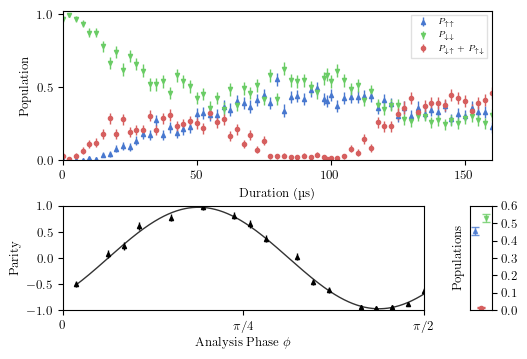

In [59]:
# creating grid for subplots
fig = plt.figure()

fig_width = gs.get_fig_width()
fig_height =  fig_width *2/3
fig.set_size_inches(fig_width, fig_height)

ax0 = plt.subplot2grid(shape=(100, 100), loc=(0, 5), colspan=100, rowspan=50)
ax1 = plt.subplot2grid(shape=(100, 100), loc=(65, 5), colspan=80, rowspan=35)
ax2 = plt.subplot2grid(shape=(100, 100), loc=(65, 95), colspan=10, rowspan=35)
ax2.yaxis.tick_right()

ax0.errorbar(
    duration,
    p00,
    yerr=p00_err,
    fmt="^",
    label=r"$P_{\uparrow\uparrow}$"
)
ax0.errorbar(
    duration,
    p11,
    yerr=p11_err,
    fmt="v",
    label=r"$P_{\downarrow\downarrow}$"
)
ax0.errorbar(
    duration,
    p01_10,
    yerr=p01_10_err,
    fmt="o",
    label=r"$P_{\downarrow\uparrow} + P_{\uparrow\downarrow}$"
)
# ax.vlines(95, -0.02, 0.5, color="k", ls="--", lw=1)
ax0.set_xlabel("Duration (µs)")
ax0.set_ylabel("Population")
ax0.set_xticks([0, 50, 100, 150])
ax0.set_yticks([0, 0.5, 1])
ax0.set_ylim(0, 1.02)
ax0.set_xlim(0, 160)
ax0.legend()

ofs = 0.01
ax2.errorbar(
    70 - ofs,
    p00_c,
    fmt="^",
    yerr=p_err_00_c,
    alpha=0.8,
    capsize=3,
    elinewidth=1.0,
)
ax2.errorbar(
    70 + ofs,
    p11_c,
    fmt="v",
    yerr=p_err_11_c,
    alpha=0.8,
    capsize=3,
    elinewidth=1.0,
)
ax2.errorbar(
    70,
    p0110_c,
    fmt="o",
    yerr=p_err_0110_c,
    capsize=3,
    elinewidth=1.0,
)
ax2.set_ylabel("Populations")
ax2.set_xlim(70 - 2 * ofs, 70 + 2 * ofs)
ax2.set_xticks([])
ax2.set_yticks(np.arange(0.0, 0.7, 0.1))
ax2.set_ylim(0.0, 0.6)


ax1.errorbar(
    phase,
    parity,
    yerr=parity_err,
    color="k",
    fmt="^")
ax1.plot(
    x_fit,
    y_fit,
    ls="-",
    color="k",
    alpha=0.8,
    label="Parity fit")
ax1.set_ylim(-1.0, 1.0)
ax1.set_xlim(np.min(phase), np.max(phase))
ax1.set_xticks([0, 0.25, 0.5], labels=[0, r"$\pi/4$", r"$\pi/2$"])
ax1.set_ylabel("Parity")
ax1.set_xlabel("Analysis Phase $\\phi$")

for ax in [ax0, ax1, ax2]:
    ax.grid(None)
plt.tight_layout()
f_name = "..\\..\\pdf_figure\\ch4\\ms_walsh_py.pdf"
plt.savefig(f_name)
